In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

import joblib

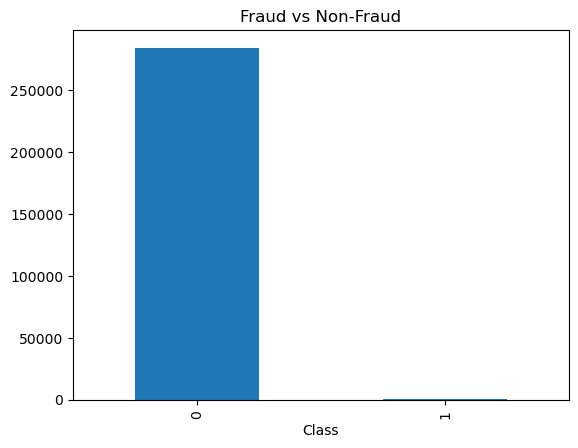

In [3]:
### 1.Load dataset and check fraud vs non-fraud counts to understand imbalance.
df = pd.read_csv('creditcard.csv')
df.head()
df['Class'].value_counts()

# Plot imbalance
df['Class'].value_counts().plot(kind='bar')
plt.title("Fraud vs Non-Fraud")
plt.show()

In [5]:
#### 2.Separate features and target column and remove non-useful identifiers.
# Drop non-useful columns (example: Time if not needed)
X = df.drop(['Class'], axis=1)
y = df['Class']
X = X.drop(['ID'], axis=1, errors='ignore')

In [6]:
#### 3.Split dataset using stratified sampling so fraud ratio stays similar in train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
#### 4.Train a baseline model like Logistic Regression for comparison.
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

In [8]:
#### 5.Train Random Forest model with parameters like n_estimators=100.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [9]:
#### 6.Predict and evaluate using precision, recall, F1-score instead of accuracy.
print("🔹 Logistic Regression Report")
print(classification_report(y_test, y_pred_lr))

print("🔹 Random Forest Report")
print(classification_report(y_test, y_pred_rf))

🔹 Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

🔹 Random Forest Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [10]:
#### 7.Plot feature importances to identify key fraud indicators.
importances = rf_model.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_df.head(10)



,Feature,Importance
17,V17,0.170325
14,V14,0.136363
12,V12,0.133326
10,V10,0.074073
16,V16,0.071792
11,V11,0.045277
9,V9,0.031127
4,V4,0.030496
18,V18,0.028156
7,V7,0.024627


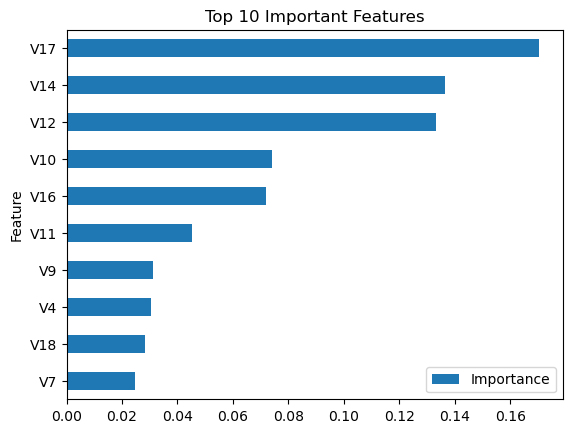

In [11]:
feat_df.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

In [12]:
#### 8.Compare Random Forest performance against baseline model.
print("Logistic Regression F1:", f1_score(y_test, y_pred_lr))
print("Random Forest F1:", f1_score(y_test, y_pred_rf))

Logistic Regression F1: 0.7167630057803468
Random Forest F1: 0.8743169398907104
